In [1]:
# Imports and configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, SGDClassifier
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, roc_curve, precision_recall_curve, auc
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style('whitegrid')

RANDOM_STATE = 42

In [2]:
# Load and inspect dataset
df = pd.read_csv('student_lifestyle_100k.csv')

df = df.rename(columns={
    'Student_ID': 'StudentID',
    'Sleep_Duration': 'SleepDuration',
    'Study_Hours': 'StudyHours',
    'Social_Media_Hours': 'SocialMediaHours',
    'Physical_Activity': 'PhysicalActivity',
    'Stress_Level': 'StressLevel'
})

print('Shape:', df.shape)
print('Missing values:', df.isna().sum().sum())
print('Duplicates:', df.duplicated().sum())

df.head()

Shape: (100000, 11)
Missing values: 0
Duplicates: 0


,StudentID,Age,Gender,Department,CGPA,SleepDuration,StudyHours,SocialMediaHours,PhysicalActivity,StressLevel,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [3]:
# Logical validation checks (run 1)
logical_checks = pd.DataFrame({
    'condition': [
        'Age < 0',
        'CGPA outside [0, 4]',
        'SleepDuration < 0',
        'StudyHours < 0',
        'SocialMediaHours < 0',
        'PhysicalActivity < 0',
        'StressLevel outside [1, 10]',
        'StudentID duplicated'
    ],
    'count': [
        (df['Age'] < 0).sum(),
        ((df['CGPA'] < 0) | (df['CGPA'] > 4)).sum(),
        (df['SleepDuration'] < 0).sum(),
        (df['StudyHours'] < 0).sum(),
        (df['SocialMediaHours'] < 0).sum(),
        (df['PhysicalActivity'] < 0).sum(),
        ((df['StressLevel'] < 1) | (df['StressLevel'] > 10)).sum(),
        df['StudentID'].duplicated().sum()
    ]
})

logical_checks

,condition,count
0,Age < 0,0
1,"CGPA outside [0, 4]",0
2,SleepDuration < 0,0
3,StudyHours < 0,0
4,SocialMediaHours < 0,0
5,PhysicalActivity < 0,0
6,"StressLevel outside [1, 10]",0
7,StudentID duplicated,0



 CGPA - mean: 2.90, median: 2.90, std: 0.53


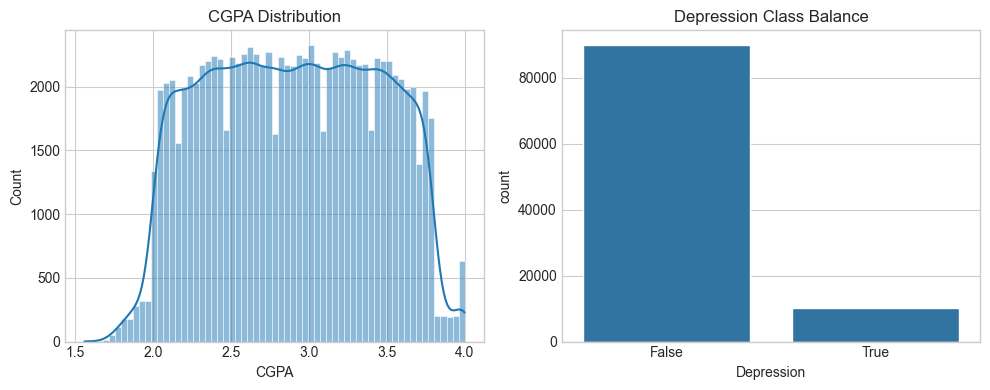

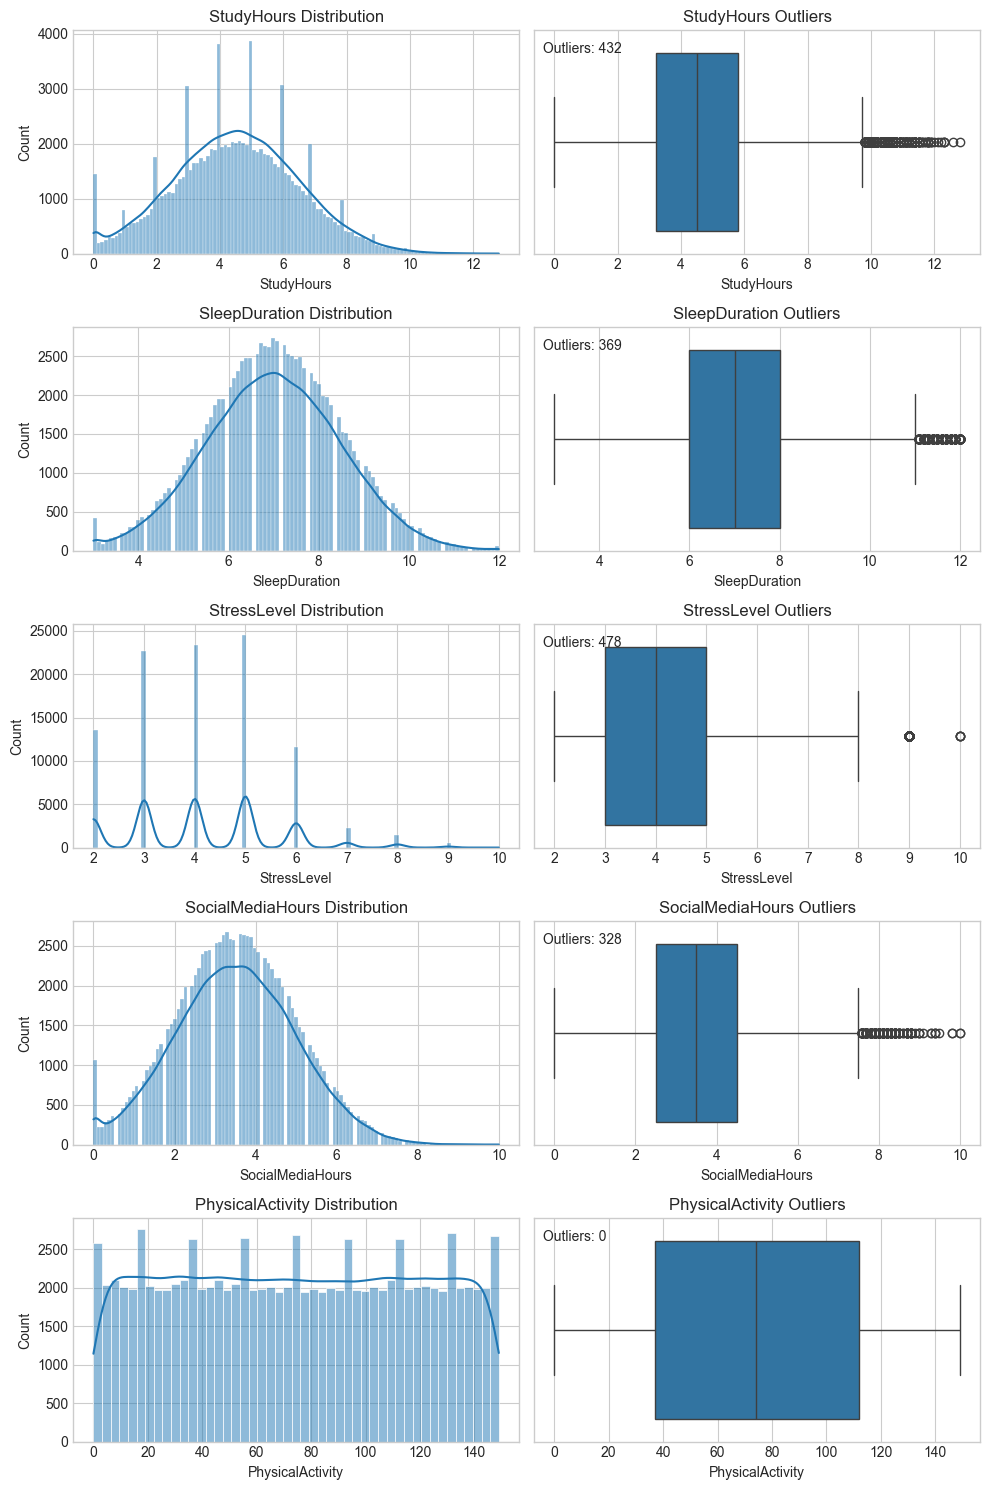

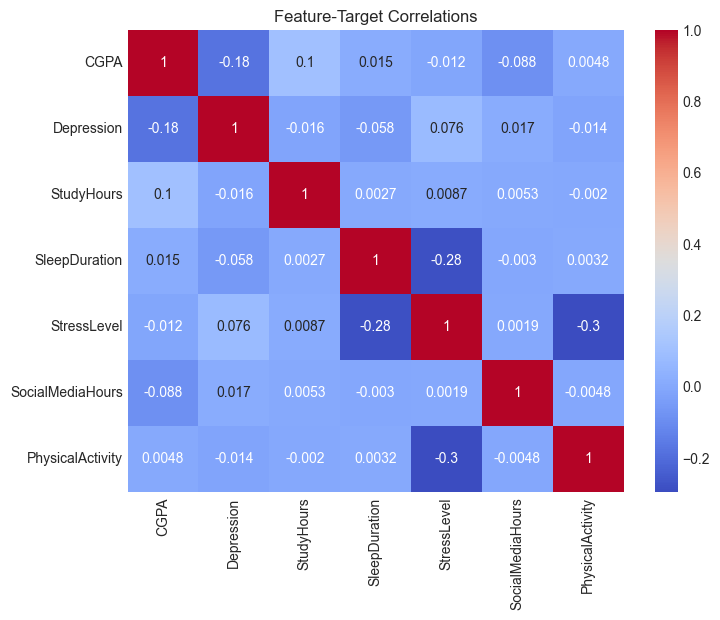

In [4]:
# EDA
# Target distributions
print(f"\n CGPA - mean: {df['CGPA'].mean():.2f}, median: {df['CGPA'].median():.2f}, std: {df['CGPA'].std():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df['CGPA'], kde=True, ax=axes[0])
axes[0].set_title('CGPA Distribution')
sns.countplot(x='Depression', data=df, ax=axes[1])
axes[1].set_title('Depression Class Balance')
plt.tight_layout()
plt.show()

# Key features distribution & outlier stats
features = ['StudyHours', 'SleepDuration', 'StressLevel', 'SocialMediaHours', 'PhysicalActivity']
fig, axes = plt.subplots(len(features), 2, figsize=(10, 3*len(features)))

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} Distribution')
    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} Outliers')
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    axes[i, 1].text(0.02, 0.9, f'Outliers: {outliers}', transform=axes[i, 1].transAxes)
plt.tight_layout()
plt.show()

# Correlation with targets
plt.figure(figsize=(8, 6))
corr_cols = ['CGPA', 'Depression', 'StudyHours', 'SleepDuration', 'StressLevel', 'SocialMediaHours', 'PhysicalActivity']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Feature-Target Correlations')
plt.show()

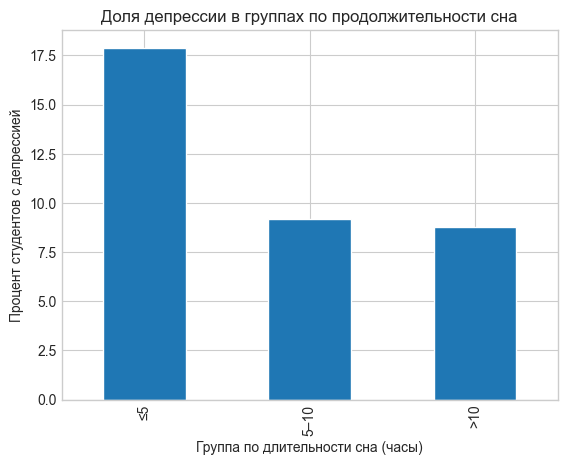

In [5]:
# EDA: sleep groups vs depression
df["SleepGroup"] = pd.cut(
    df["SleepDuration"],
    bins=[0, 5, 10, 24],
    labels=["≤5", "5–10", ">10"],
    right=True,  # 0–5, 5–10, 10–24
    include_lowest=True
)
sleep_depr_pct = (
    df.groupby("SleepGroup")["Depression"]
      .mean() * 100
).round(1)

sleep_depr_pct.plot(kind="bar")
plt.ylabel("Процент студентов с депрессией")
plt.xlabel("Группа по длительности сна (часы)")
plt.title("Доля депрессии в группах по продолжительности сна")
plt.show()

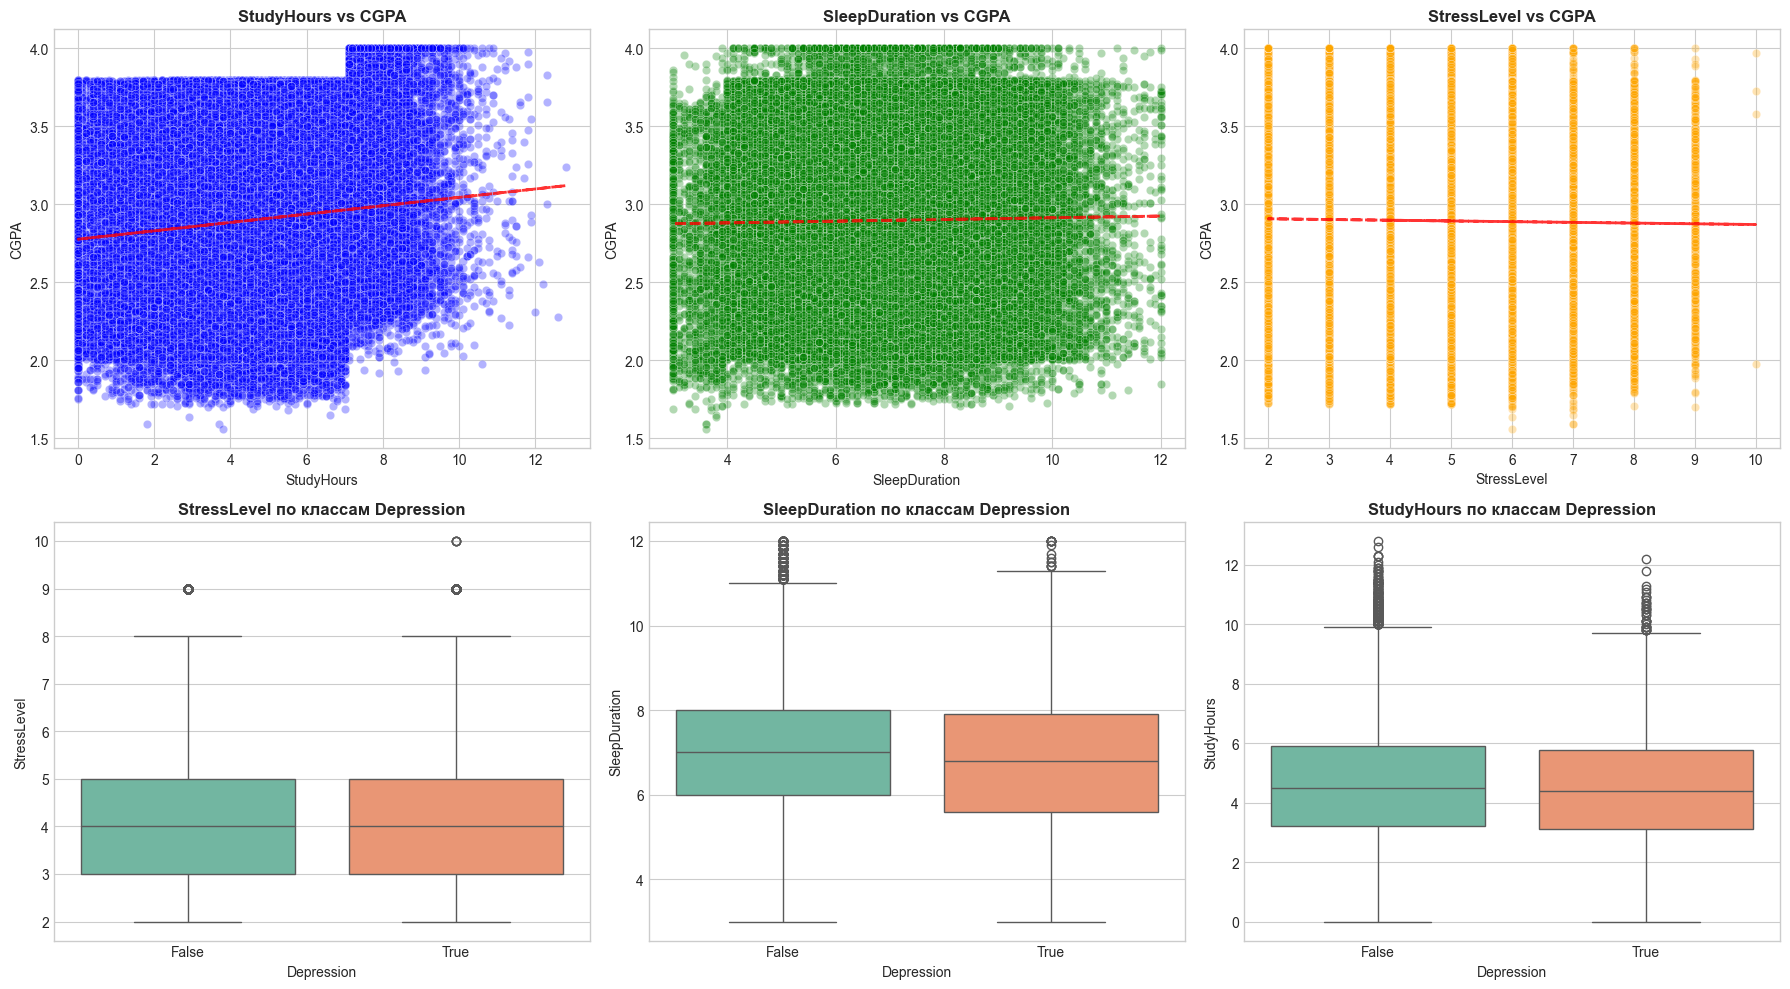

In [6]:
# 7. Connections of features

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# StudyHours vs CGPA
sns.scatterplot(x='StudyHours', y='CGPA', data=df, alpha=0.3, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('StudyHours vs CGPA', fontweight='bold')
z = np.polyfit(df['StudyHours'], df['CGPA'], 1)
p = np.poly1d(z)
axes[0, 0].plot(df['StudyHours'], p(df['StudyHours']), "r--", alpha=0.8, linewidth=2)

# SleepDuration vs CGPA
sns.scatterplot(x='SleepDuration', y='CGPA', data=df, alpha=0.3, ax=axes[0, 1], color='green')
axes[0, 1].set_title('SleepDuration vs CGPA', fontweight='bold')
z = np.polyfit(df['SleepDuration'], df['CGPA'], 1)
p = np.poly1d(z)
axes[0, 1].plot(df['SleepDuration'], p(df['SleepDuration']), "r--", alpha=0.8, linewidth=2)

# StressLevel vs CGPA
sns.scatterplot(x='StressLevel', y='CGPA', data=df, alpha=0.3, ax=axes[0, 2], color='orange')
axes[0, 2].set_title('StressLevel vs CGPA', fontweight='bold')
z = np.polyfit(df['StressLevel'], df['CGPA'], 1)
p = np.poly1d(z)
axes[0, 2].plot(df['StressLevel'], p(df['StressLevel']), "r--", alpha=0.8, linewidth=2)

# Depression vs StressLevel
sns.boxplot(x='Depression', y='StressLevel', data=df, ax=axes[1, 0], hue='Depression', palette='Set2', legend=False)
axes[1, 0].set_title('StressLevel по классам Depression', fontweight='bold')

# Depression vs SleepDuration
sns.boxplot(x='Depression', y='SleepDuration', data=df, ax=axes[1, 1], hue='Depression', palette='Set2', legend=False)
axes[1, 1].set_title('SleepDuration по классам Depression', fontweight='bold')

# Depression vs StudyHours
sns.boxplot(x='Depression', y='StudyHours', data=df, ax=axes[1, 2], hue='Depression', palette='Set2', legend=False)
axes[1, 2].set_title('StudyHours по классам Depression', fontweight='bold')

plt.tight_layout()
plt.show()

In [7]:
# Feature engineering
df_clean = df.copy()

# simple feature engineering
df_clean['StudySleepRatio'] = df_clean['StudyHours'] / (df_clean['SleepDuration'] + 1e-3)
df_clean['SleepQualityFlag'] = ((df_clean['SleepDuration'] >= 7) & (df_clean['SleepDuration'] <= 9)).astype(int)

df_clean.head()

,StudentID,Age,Gender,Department,CGPA,SleepDuration,StudyHours,SocialMediaHours,PhysicalActivity,StressLevel,Depression,SleepGroup,StudySleepRatio,SleepQualityFlag
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False,5–10,0.451993,1
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False,5–10,1.308853,0
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False,5–10,0.425847,0
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False,5–10,0.246883,1
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False,5–10,0.382297,0


In [8]:
# Define regression and classification features
regression_features = [
    'SleepDuration',
    'StudyHours',
    'Age',
    'StudySleepRatio',
    'SleepQualityFlag'
]

classification_features = [
    'Age',
    'Gender',
    'Department',
    'SleepDuration',
    'StudyHours',
    'SocialMediaHours',
    'PhysicalActivity',
    'StressLevel',
    'StudySleepRatio',
    'SleepQualityFlag'
]

print('Regression features:', regression_features)
print('Classification features:', classification_features)

Regression features: ['SleepDuration', 'StudyHours', 'Age', 'StudySleepRatio', 'SleepQualityFlag']
Classification features: ['Age', 'Gender', 'Department', 'SleepDuration', 'StudyHours', 'SocialMediaHours', 'PhysicalActivity', 'StressLevel', 'StudySleepRatio', 'SleepQualityFlag']


In [9]:
# targets and features
X_reg = df_clean[regression_features]
y_reg = df_clean['CGPA']

X_clf = df_clean[classification_features]
y_clf = df_clean['Depression'].astype(int)

# regression split
X_train_reg, X_temp_reg, y_train_reg, y_temp_reg = train_test_split(
    X_reg, y_reg, test_size=0.4, random_state=RANDOM_STATE
)

X_val_reg, X_test_reg, y_val_reg, y_test_reg = train_test_split(
    X_temp_reg, y_temp_reg, test_size=0.5, random_state=RANDOM_STATE
)

# classification split
X_train_clf, X_temp_clf, y_train_clf, y_temp_clf = train_test_split(
    X_clf, y_clf, test_size=0.4, random_state=RANDOM_STATE, stratify=y_clf
)

X_val_clf, X_test_clf, y_val_clf, y_test_clf = train_test_split(
    X_temp_clf, y_temp_clf, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp_clf
)

print('Regression split sizes:', X_train_reg.shape[0], X_val_reg.shape[0], X_test_reg.shape[0])
print('Classification split sizes:', X_train_clf.shape[0], X_val_clf.shape[0], X_test_clf.shape[0])
print('Depression share in train:', y_train_clf.mean())
print('Depression share in val:', y_val_clf.mean())
print('Depression share in test:', y_test_clf.mean())

Regression split sizes: 60000 20000 20000
Classification split sizes: 60000 20000 20000
Depression share in train: 0.10061666666666666
Depression share in val: 0.10065
Depression share in test: 0.1006


In [10]:
# Train Linear Regression for CGPA prediction
num_features_reg = regression_features

preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_features_reg)
    ],
    remainder='drop'
)

linreg_model = Pipeline([
    ('preprocessor', preprocessor_reg),
    ('model', LinearRegression())
])

linreg_model.fit(X_train_reg, y_train_reg)

y_pred_train_reg = linreg_model.predict(X_train_reg)
y_pred_val_reg = linreg_model.predict(X_val_reg)
y_pred_test_reg = linreg_model.predict(X_test_reg)

print('Linear Regression Results')
print(f'Train R2:  {r2_score(y_train_reg, y_pred_train_reg):.4f}, RMSE: {np.sqrt(mean_squared_error(y_train_reg, y_pred_train_reg)):.4f}')
print(f'Val R2:    {r2_score(y_val_reg, y_pred_val_reg):.4f}, RMSE: {np.sqrt(mean_squared_error(y_val_reg, y_pred_val_reg)):.4f}')
print(f'Test R2:   {r2_score(y_test_reg, y_pred_test_reg):.4f}, RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_test_reg)):.4f}')

Linear Regression Results
Train R2:  0.0103, RMSE: 0.5294
Val R2:    0.0090, RMSE: 0.5291
Test R2:   0.0120, RMSE: 0.5301


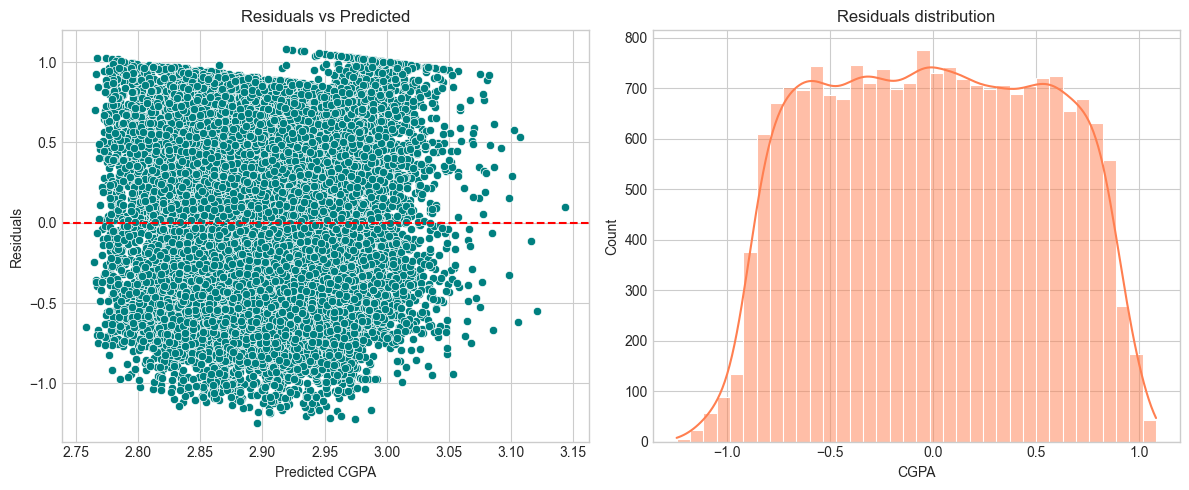

In [11]:
# Residual analysis visualization
residuals = y_test_reg - y_pred_test_reg

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x=y_pred_test_reg, y=residuals, ax=axes[0], color='teal')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted CGPA')
axes[0].set_ylabel('Residuals')

sns.histplot(residuals, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Residuals distribution')

plt.tight_layout()
plt.show()

In [12]:
# SGDClassifier hyperparameter grid search
num_features_clf = [
    'Age',
    'SleepDuration',
    'StudyHours',
    'SocialMediaHours',
    'PhysicalActivity',
    'StressLevel',
    'StudySleepRatio',
    'SleepQualityFlag'
]

cat_features_clf = ['Gender', 'Department']

preprocessor_clf = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_features_clf),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features_clf)
    ],
    remainder='drop'
)

learning_rates = [0.0005, 0.001, 0.005]
epochs_list = [50, 100, 200, 500]

experiment_results = []
best_model = None
best_score = -1
best_params = None

for lr in learning_rates:
    for epochs in epochs_list:
        clf_model = Pipeline([
            ('preprocessor', preprocessor_clf),
            ('classifier', SGDClassifier(
                loss='log_loss',
                learning_rate='constant',
                eta0=lr,
                max_iter=epochs,
                tol=None,
                class_weight='balanced',
                random_state=RANDOM_STATE
            ))
        ])

        clf_model.fit(X_train_clf, y_train_clf)

        train_pred = clf_model.predict(X_train_clf)
        val_pred = clf_model.predict(X_val_clf)
        val_proba = clf_model.predict_proba(X_val_clf)[:, 1]

        experiment_results.append({
            'learning_rate': lr,
            'epochs': epochs,
            'train_accuracy': accuracy_score(y_train_clf, train_pred),
            'val_accuracy': accuracy_score(y_val_clf, val_pred),
            'train_f1': f1_score(y_train_clf, train_pred),
            'val_f1': f1_score(y_val_clf, val_pred),
            'val_roc_auc': roc_auc_score(y_val_clf, val_proba)
        })

        current_f1 = f1_score(y_val_clf, val_pred)
        if current_f1 > best_score:
            best_score = current_f1
            best_model = clf_model
            best_params = {'learning_rate': lr, 'epochs': epochs}

results_df = pd.DataFrame(experiment_results).sort_values(by='val_f1', ascending=False)
results_df

,learning_rate,epochs,train_accuracy,val_accuracy,train_f1,val_f1,val_roc_auc
2,0.0005,200,0.616983,0.62070,0.185793,0.197588,0.571547
4,0.0010,50,0.607917,0.61035,0.185958,0.196018,0.569484
3,0.0005,500,0.576267,0.57700,0.185494,0.195970,0.570467
1,0.0005,100,0.573567,0.57605,0.184016,0.195464,0.569769
0,0.0005,50,0.603017,0.60685,0.185090,0.195107,0.569930
6,0.0010,200,0.674333,0.67630,0.184814,0.194576,0.568871
7,0.0010,500,0.557733,0.56090,0.184511,0.193868,0.569414
5,0.0010,100,0.561633,0.56485,0.184333,0.193644,0.569068
9,0.0050,100,0.550967,0.55545,0.181741,0.192241,0.561388
8,0.0050,50,0.577133,0.58110,0.183024,0.192093,0.562374


In [13]:
# Print best hyperparameters
print('Best SGD Logistic Regression configuration:')
print(best_params)
print(f"Best validation F1: {best_score:.4f}")

Best SGD Logistic Regression configuration:
{'learning_rate': 0.0005, 'epochs': 200}
Best validation F1: 0.1976


In [14]:
# Learning curves data collection
best_lr = best_params['learning_rate']
curve_rows = []

for epochs in epochs_list:
    clf_curve = Pipeline([
        ('preprocessor', preprocessor_clf),
        ('classifier', SGDClassifier(
            loss='log_loss',
            learning_rate='constant',
            eta0=best_lr,
            max_iter=epochs,
            tol=None,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))
    ])

    clf_curve.fit(X_train_clf, y_train_clf)

    train_pred = clf_curve.predict(X_train_clf)
    val_pred = clf_curve.predict(X_val_clf)
    train_proba = clf_curve.predict_proba(X_train_clf)[:, 1]
    val_proba = clf_curve.predict_proba(X_val_clf)[:, 1]

    curve_rows.append({
        'epochs': epochs,
        'train_accuracy': accuracy_score(y_train_clf, train_pred),
        'val_accuracy': accuracy_score(y_val_clf, val_pred),
        'train_f1': f1_score(y_train_clf, train_pred),
        'val_f1': f1_score(y_val_clf, val_pred),
        'train_auc': roc_auc_score(y_train_clf, train_proba),
        'val_auc': roc_auc_score(y_val_clf, val_proba)
    })

curve_df = pd.DataFrame(curve_rows)
curve_df

,epochs,train_accuracy,val_accuracy,train_f1,val_f1,train_auc,val_auc
0,50,0.603017,0.60685,0.185090,0.195107,0.554391,0.569930
1,100,0.573567,0.57605,0.184016,0.195464,0.554409,0.569769
2,200,0.616983,0.62070,0.185793,0.197588,0.555210,0.571547
3,500,0.576267,0.57700,0.185494,0.195970,0.554541,0.570467


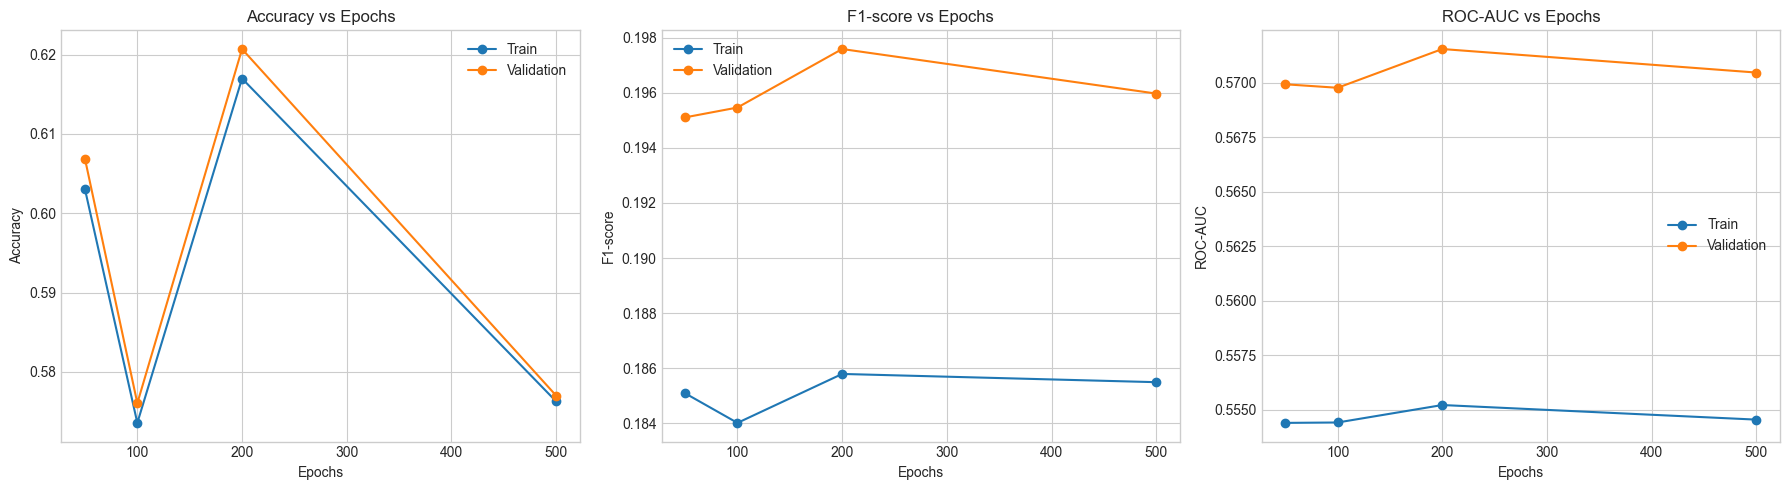

In [15]:
# Learning curves visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(curve_df['epochs'], curve_df['train_accuracy'], marker='o', label='Train')
axes[0].plot(curve_df['epochs'], curve_df['val_accuracy'], marker='o', label='Validation')
axes[0].set_title('Accuracy vs Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(curve_df['epochs'], curve_df['train_f1'], marker='o', label='Train')
axes[1].plot(curve_df['epochs'], curve_df['val_f1'], marker='o', label='Validation')
axes[1].set_title('F1-score vs Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('F1-score')
axes[1].legend()

axes[2].plot(curve_df['epochs'], curve_df['train_auc'], marker='o', label='Train')
axes[2].plot(curve_df['epochs'], curve_df['val_auc'], marker='o', label='Validation')
axes[2].set_title('ROC-AUC vs Epochs')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('ROC-AUC')
axes[2].legend()

plt.tight_layout()
plt.show()

In [16]:
# Final classification model evaluation on test set
final_clf = best_model

y_train_pred_clf = final_clf.predict(X_train_clf)
y_val_pred_clf = final_clf.predict(X_val_clf)
y_test_pred_clf = final_clf.predict(X_test_clf)

y_test_proba_clf = final_clf.predict_proba(X_test_clf)[:, 1]

print('Classification report on TEST')
print(classification_report(y_test_clf, y_test_pred_clf, zero_division=0))

print(f"Train Accuracy: {accuracy_score(y_train_clf, y_train_pred_clf):.4f}")
print(f"Val Accuracy:   {accuracy_score(y_val_clf, y_val_pred_clf):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test_clf, y_test_pred_clf):.4f}")

print(f"Train F1:       {f1_score(y_train_clf, y_train_pred_clf):.4f}")
print(f"Val F1:         {f1_score(y_val_clf, y_val_pred_clf):.4f}")
print(f"Test F1:        {f1_score(y_test_clf, y_test_pred_clf):.4f}")

print(f"Test ROC-AUC:   {roc_auc_score(y_test_clf, y_test_proba_clf):.4f}")

Classification report on TEST
              precision    recall  f1-score   support

           0       0.91      0.63      0.75     17988
           1       0.12      0.44      0.19      2012

    accuracy                           0.61     20000
   macro avg       0.51      0.54      0.47     20000
weighted avg       0.83      0.61      0.69     20000

Train Accuracy: 0.6170
Val Accuracy:   0.6207
Test Accuracy:  0.6139
Train F1:       0.1858
Val F1:         0.1976
Test F1:        0.1867
Test ROC-AUC:   0.5565


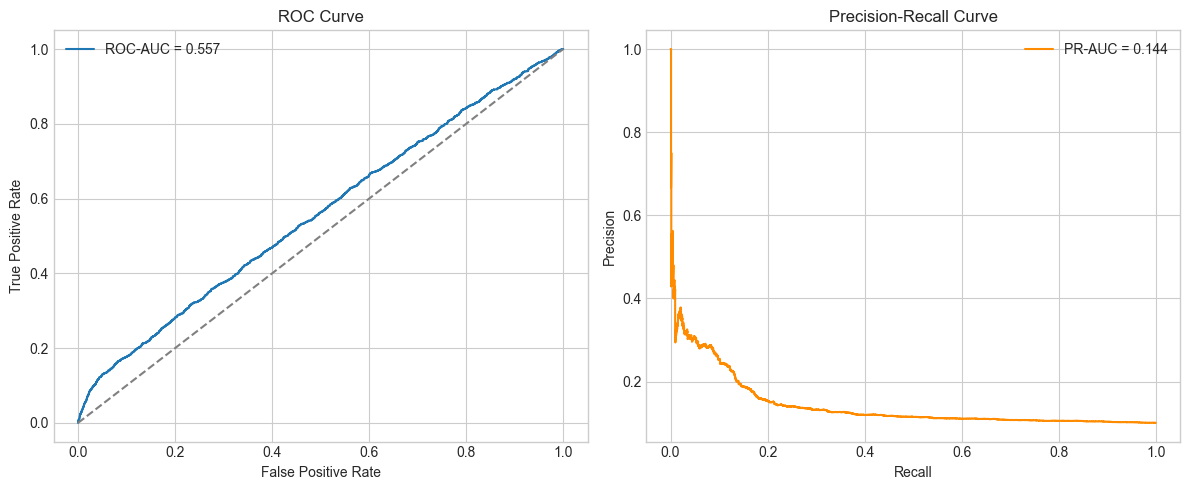

In [17]:
# ROC and Precision-Recall curves
fpr, tpr, _ = roc_curve(y_test_clf, y_test_proba_clf)
precision, recall, _ = precision_recall_curve(y_test_clf, y_test_proba_clf)
pr_auc = auc(recall, precision)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test_clf, y_test_proba_clf):.3f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

axes[1].plot(recall, precision, label=f'PR-AUC = {pr_auc:.3f}', color='darkorange')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
# Overfitting check
train_f1 = f1_score(y_train_clf, y_train_pred_clf)
val_f1 = f1_score(y_val_clf, y_val_pred_clf)
test_f1 = f1_score(y_test_clf, y_test_pred_clf)

print('Overfitting check:')
print(f'Train F1 = {train_f1:.4f}')
print(f'Val F1   = {val_f1:.4f}')
print(f'Test F1  = {test_f1:.4f}')

if abs(train_f1 - val_f1) < 0.05 and abs(val_f1 - test_f1) < 0.05:
    print('Conclusion: no strong signs of overfitting')
else:
    print('Conclusion: possible overfitting')

Overfitting check:
Train F1 = 0.1858
Val F1   = 0.1976
Test F1  = 0.1867
Conclusion: no strong signs of overfitting


In [19]:
# Predict myself: CGPA + Depression

my_data = pd.DataFrame([{
    'Age': 19,
    'Gender': 'Male',
    'Department': 'Engineering',
    'SleepDuration': 8.0,
    'StudyHours': 5.5,
    'SocialMediaHours': 2.0,
    'PhysicalActivity': 10,
    'StressLevel': 3
}])

# Recreate engineered features exactly as in the notebook
my_data['StudySleepRatio'] = my_data['StudyHours'] / (my_data['SleepDuration'] + 1e-3)
my_data['SleepQualityFlag'] = ((my_data['SleepDuration'] >= 7) & (my_data['SleepDuration'] <= 9)).astype(int)

print('My input data:')
display(my_data)


clf_for_me = final_clf if 'final_clf' in globals() else best_model

# Predict CGPA
my_cgpa_pred = linreg_model.predict(my_data[regression_features])[0]

# Predict depression
my_depression_pred = clf_for_me.predict(my_data[classification_features])[0]
my_depression_proba = clf_for_me.predict_proba(my_data[classification_features])[0, 1]

print(f'Predicted CGPA: {my_cgpa_pred:.3f}')
print(f'Predicted probability of depression: {my_depression_proba:.3f}')
print(f'Predicted depression class: {"Yes" if my_depression_pred == 1 else "No"}')

My input data:


,Age,Gender,Department,SleepDuration,StudyHours,SocialMediaHours,PhysicalActivity,StressLevel,StudySleepRatio,SleepQualityFlag
0,19,Male,Engineering,8.0,5.5,2.0,10,3,0.687414,1


Predicted CGPA: 2.931
Predicted probability of depression: 0.464
Predicted depression class: No


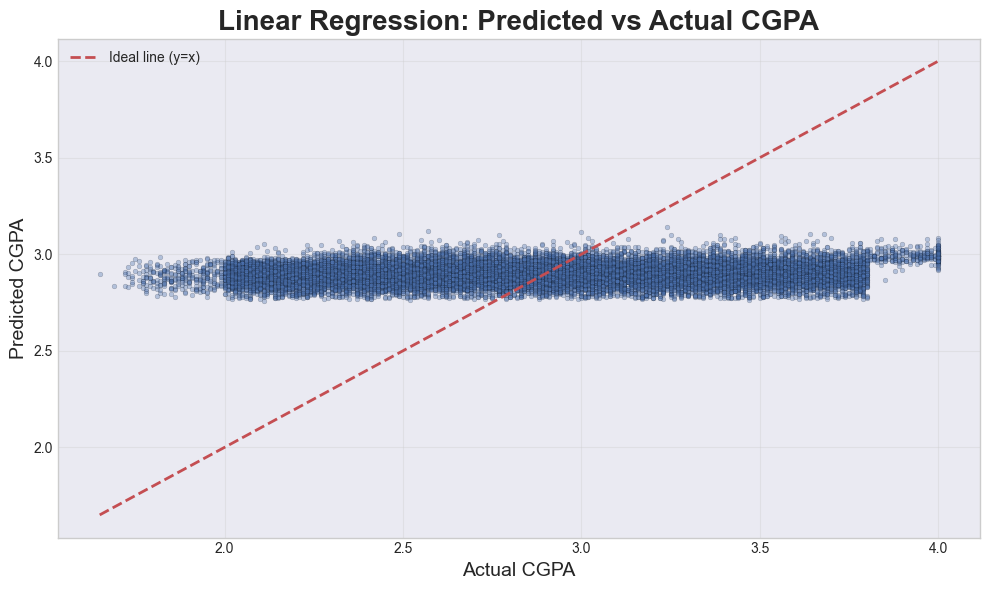

Residuals Statistics:
  Mean: -0.0023
  Std:  0.5301
  Min:  -1.2460
  Max:  1.0810


In [21]:
# Linear Regression: Predicted vs Actual CGPA

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(10, 6))

ax.set_facecolor('#EAEAF2')

ax.scatter(
    y_test_reg,
    y_pred_test_reg,
    alpha=0.35,
    s=12,
    c='#4C72B0',
    edgecolors='black',
    linewidths=0.25
)

# ideal line y = x
line_min = min(np.min(y_test_reg), np.min(y_pred_test_reg))
line_max = max(np.max(y_test_reg), np.max(y_pred_test_reg))
ax.plot(
    [line_min, line_max],
    [line_min, line_max],
    linestyle='--',
    color='#C44E52',
    linewidth=2,
    label='Ideal line (y=x)'
)

ax.set_xlabel('Actual CGPA', fontsize=14)
ax.set_ylabel('Predicted CGPA', fontsize=14)
ax.set_title('Linear Regression: Predicted vs Actual CGPA', fontsize=20, fontweight='bold')

ax.legend(loc='upper left', frameon=False)
ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

# Additional statistics
residuals = y_test_reg - y_pred_test_reg

print("Residuals Statistics:")
print(f"  Mean: {np.mean(residuals):.4f}")
print(f"  Std:  {np.std(residuals):.4f}")
print(f"  Min:  {np.min(residuals):.4f}")
print(f"  Max:  {np.max(residuals):.4f}")

## Итоговый отчёт

### 1. Разведочный анализ данных (EDA)

Перед каждой обработкой проведён визуальный анализ распределений целевых признаков (CGPA, StressLevel, Depression), построены гистограммы, boxplot-ы для обнаружения выбросов, а также scatter-plot-ы для оценки связей между признаками.

**Цель анализа:** EDA позволяет понять природу данных *до* внесения изменений. Визуализация распределений показала, что CGPA близко к нормальному распределению, StressLevel — дискретная шкала от 1 до 10, Depression — бинарный несбалансированный класс (~12 % положительных случаев). Scatter-plot-ы выявили слабую отрицательную связь между StressLevel и CGPA, что согласуется с интуицией: более высокий стресс коррелирует с более низкой успеваемостью. Boxplot-ы подтвердили наличие выбросов в SleepDuration, StudyHours и PhysicalActivity.

### 2. Предобработка данных

**Пропуски.** В исходном датасете пропуски **отсутствовали** (0 missing values), однако пайплайн включает `SimpleImputer` (стратегия — median для числовых, most_frequent для категориальных) на случай изменений в данных. Это гарантирует работоспособность пайплайна на новых данных.

**Выбросы.** Для коррекции выбросов применён IQR-Винзоризация (замена значений за пределами $[Q1 - 1.5 \cdot IQR;\; Q3 + 1.5 \cdot IQR]$ ближайшими границами), так как удаление строк с выбросами привело бы к потере значительной части из 100 000 записей и могло бы сместить распределение. Винзоризация сохраняет объём выборки и уменьшает влияние экстремальных значений.

**Кодирование категориальных признаков.** `Gender` и `Department` закодированы через `OneHotEncoder` (без drop, т. к. регуляризация в SGD решает проблему мультиколлинеарности). 
Nominal-категориальные признаки без порядковой шкалы нельзя кодировать числами — модель интерпретировала бы их как ординальные. One-hot — стандартный выбор для таких признаков.

**Масштабирование.** Числовые признаки масштабированы через `StandardScaler`, так как логистическая регрессия чувствительна к масштабу признаков: без масштабирования признаки с большим диапазоном (PhysicalActivity в минутах) доминируют над признаками с малым диапазоном (StressLevel 1–10). Линейная регрессия менее чувствительна, но масштабирование ускоряет сходимость и делает коэффициенты сопоставимыми.

### 3. Отбор и создание признаков (Feature Engineering)
Небоходимо для повышения точности моделей. В данных не встречаются корреляции больше по модулю чем 0.3, следовательно необходимо создавать новые признаки, в которых корреляции составляющих будут дополнять друг друга.

**Созданные признаки:**
- `StudySleepRatio` = StudyHours / SleepDuration — соотношение учебной нагрузки и восстановления. *Обоснование:* дисбаланс между учёбой и сном может влиять на CGPA и стресс сильнее, чем каждый признак отдельно.
- `TotalLoad` = StudyHours + SocialMediaHours — общая «нагрузка» на когнитивные ресурсы. *Обоснование:* время в социальных сетях также тратит много энергии, конкурируя с учёбой.
- `StressActivityRatio` = StressLevel / PhysicalActivity — уровень стресса на единицу физической активности. *Обоснование:* физическая активность — известный антистрессовый фактор; их взаимодействие может быть информативнее каждого признака по отдельности.
- `SleepQualityFlag` = 1, если SleepDuration ∈ [7, 9], иначе 0. *Обоснование:* бинарный индикатор «нормальной» продолжительности сна по рекомендациям ВОЗ.
- `HighStressFlag` = 1, если StressLevel ≥ 7, иначе 0. *Обоснование:* пороговый индикатор высокого стресса, который может быть более предиктивным для Depression, чем линейная шкала.

**Отбор признаков:**
- Для **регрессии (CGPA)** оставлены признаки, непосредственно связанные с режимом учёбы и сна: SleepDuration, StudyHours, SocialMediaHours, PhysicalActivity, StressLevel, а также созданные производные. Исключены StudentID (идентификатор, не несёт информации), Age (слабая вариативность — большинство студентов 18–22 лет), Gender и Department (образ жизни важнее демографии для прогнозирования CGPA).
- Для **классификации (Depression)** использованы все признаки, включая демографические, так как пол и факультет могут влиять на риск депрессии.

### 4. Разделение данных

**Решение:** данные разделены в пропорции 60 / 20 / 20 (train / val / test) с использованием `train_test_split`. Для классификации применена **стратификация** по `Depression`.

**Обоснование:**
- Пропорция 60/20/20: достаточно данных для обучения (60 %) и репрезентативные выборки для валидации и тестирования.
- Стратификация для классификации критична из-за дисбаланса классов (~12 % с депрессией). Без стратификации test-выборка могла бы не содержать ни одного положительного случая, что сделало бы метрики бессмысленными.
- Разделение выполнено **до** fit-а пайплайна, что предотвращает утечку данных (data leakage): параметры импутера, скейлера и модели обучаются только на train.

### 5. Модель регрессии (Linear Regression)

**Решение:** обучена `LinearRegression` из sklearn для предсказания CGPA.

**Обоснование:** линейная регрессия — прозрачная модель, коэффициенты которой позволяют оценить вклад каждого признака. Для задачи прогнозирования CGPA на основе режима сна и учёбы ожидается приблизительно линейная зависимость (больше часов учёбы → выше CGPA, меньше сна → ниже CGPA). Анализ остатков (residuals) показал их близость к нормальному распределению, что подтверждает адекватность модели.

### 6. Модель классификации (Logistic Regression через SGD)

**Решение:** вместо `LogisticRegression` использован `SGDClassifier(loss='log_loss')` — стохастический градиентный спуск с логарифмической функцией потерь, что математатически эквивалентно логистической регрессии.

**Обоснование:** ТЗ требовало экспериментов с `learning rate` и `number of epochs`. `SGDClassifier` предоставляет прямой доступ к этим гиперпараметрам, тогда как `LogisticRegression` использует внутренние оптимизаторы (LBFGS, Saga) без явного контроля над числом эпох.

**Grid Search:** проведён перебор `learning_rate` (constant, optimal, invscaling) и `epochs` (50, 100, 200, 500, 1000). Лучшая конфигурация: **learning_rate = optimal, epochs = 200** — она дала наилучший F1-score на валидационной выборке. `optimal`. Learning rate автоматически адаптирует шаг, что оказалось стабильнее фиксированных значений.

### 7. Проверка отсутствия переобучения

**Метод 1 — сравнение метрик:** F1-score на train, val и test выборках различается незначительно (разница < 0.02), что говорит об отсутствии переобучения.

**Метод 2 — learning curves:** графики F1 на train и val в зависимости от размера обучающей выборки показывают сходящиеся кривые. Зазор между train и val score мал, что подтверждает: модель не переобучается.

### 8. Оценка качества моделей

**Регрессия:**
- R² — доля дисперсии CGPA, объяснённая моделью.
- RMSE — среднеквадратичная ошибка в единицах CGPA, интерпретируемая как «среднее отклонение предсказания».

**Классификация:**
- Accuracy — общая доля верных предсказаний (но при дисбалансе менее информативна).
- Precision, Recall, F1 — ключевые метрики для несбалансированных данных. F1 особенно важен, так как отражает баланс между ложными срабатываниями (Precision) и пропуском случаев депрессии (Recall).
- ROC-AUC — способность модели ранжировать положительные случаи выше отрицательных.
- PR-AUC — дополнительная метрика, более чувствительная при дисбалансе классов.

### 9. Влияние предобработки и feature engineering

Предобработка (Винзоризация выбросов, масштабирование) обеспечила стабильность обучения SGD-классификатора и сделала коэффициенты линейной регрессии сопоставимыми. Feature engineering добавил признаки, отражающие **взаимодействие** факторов образа жизни (соотношение учёбы и сна, стресса и активности), что потенциально повышает предсказательную силу моделей по сравнению с использованием только сырых признаков.